In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),
    HybridPoolingV0(30),          # 32 → 16

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    HybridPoolingV0(60),          # 16 → 8

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    HybridPoolingV0(60),          # 8 → 4

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    HybridPoolingV0(60),          # 4 → 2

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model37_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model37_0)
describe(model37_0)

MACs: 5.36 MMac, Params: 37.23 k
Layer (type:depth-idx)                        Output Shape              Param #
BaseModelF32                                  [1, 10]                   --
├─ModuleList: 1-1                             --                        --
│    └─Sequential: 2-1                        [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1                  [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                       [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9                  [1, 30, 32, 32] 

Loading checkpoint from model_weights/model37_0.pt
Starting
Epoch 1/60: Train loss = 1.0876, Train accuracy = 0.6190, Test loss = 1.0945, Test accuracy = 0.6226
Epoch 2/60: Train loss = 0.8685, Train accuracy = 0.6918, Test loss = 0.8714, Test accuracy = 0.6940
Epoch 3/60: Train loss = 0.7776, Train accuracy = 0.7356, Test loss = 0.8217, Test accuracy = 0.7314
Epoch 4/60: Train loss = 0.6870, Train accuracy = 0.7605, Test loss = 0.7380, Test accuracy = 0.7541
Epoch 5/60: Train loss = 0.6159, Train accuracy = 0.7828, Test loss = 0.6765, Test accuracy = 0.7703
Epoch 6/60: Train loss = 0.5672, Train accuracy = 0.8045, Test loss = 0.6179, Test accuracy = 0.7987
Epoch 7/60: Train loss = 0.5604, Train accuracy = 0.8045, Test loss = 0.6170, Test accuracy = 0.7910
Epoch 8/60: Train loss = 0.5838, Train accuracy = 0.7988, Test loss = 0.6346, Test accuracy = 0.7901
Epoch 9/60: Train loss = 0.5250, Train accuracy = 0.8169, Test loss = 0.5896, Test accuracy = 0.8061
Epoch 10/60: Train loss = 0.486

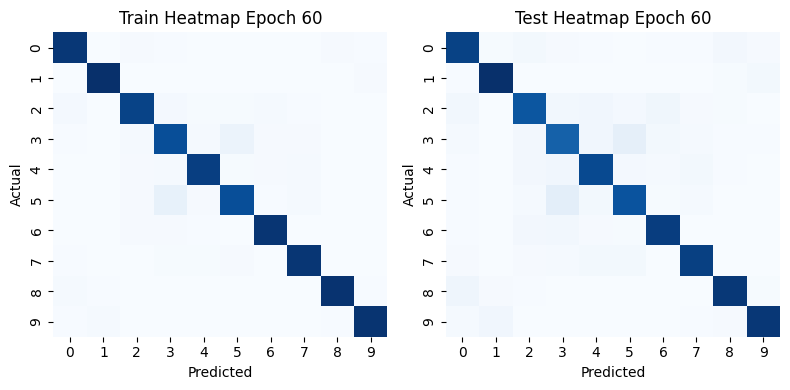

<Figure size 1200x600 with 0 Axes>

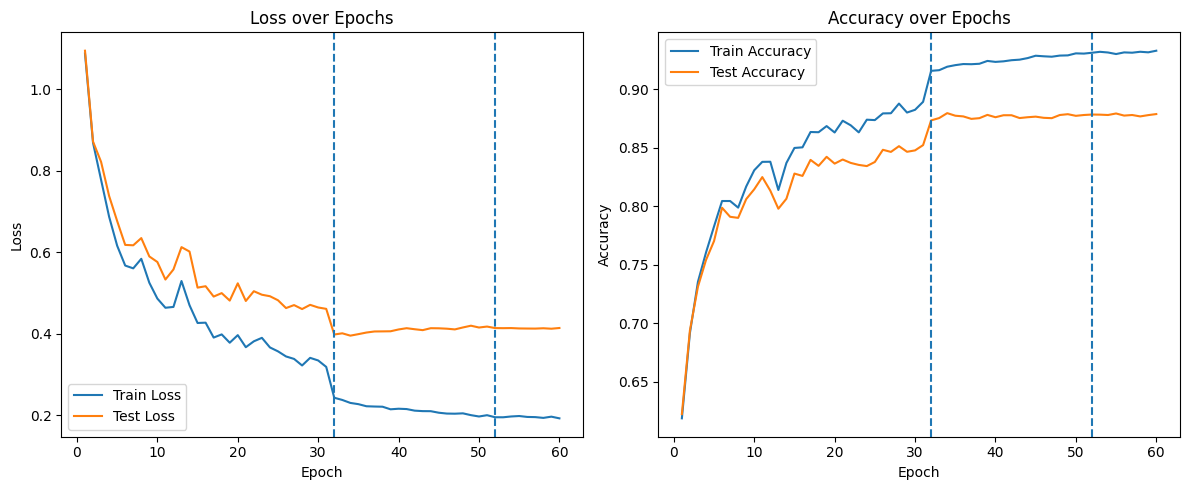

In [6]:
trainf32(model37_0,"model_weights/model37_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model37_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model37_1)
describe(model37_1)

MACs: 5.36 MMac, Params: 37.23 k
Layer (type:depth-idx)                        Output Shape              Param #
BaseModelF32                                  [1, 10]                   --
├─ModuleList: 1-1                             --                        --
│    └─Sequential: 2-1                        [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1                  [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                       [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6                  [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                        [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                       [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9                  [1, 30, 32, 32] 

Loading checkpoint from model_weights/model37_1.pt
Starting
Epoch 1/60: Train loss = 0.9008, Train accuracy = 0.6850, Test loss = 0.8713, Test accuracy = 0.6997
Epoch 2/60: Train loss = 0.7318, Train accuracy = 0.7438, Test loss = 0.7290, Test accuracy = 0.7469
Epoch 3/60: Train loss = 0.6236, Train accuracy = 0.7843, Test loss = 0.6376, Test accuracy = 0.7820
Epoch 4/60: Train loss = 0.6258, Train accuracy = 0.7796, Test loss = 0.6455, Test accuracy = 0.7790
Epoch 5/60: Train loss = 0.6141, Train accuracy = 0.7887, Test loss = 0.6531, Test accuracy = 0.7804
Epoch 6/60: Train loss = 0.5530, Train accuracy = 0.8113, Test loss = 0.6061, Test accuracy = 0.8043
Epoch 7/60: Train loss = 0.5166, Train accuracy = 0.8215, Test loss = 0.5602, Test accuracy = 0.8130
Epoch 8/60: Train loss = 0.4909, Train accuracy = 0.8304, Test loss = 0.5292, Test accuracy = 0.8202
Epoch 9/60: Train loss = 0.4538, Train accuracy = 0.8436, Test loss = 0.5008, Test accuracy = 0.8271
Epoch 10/60: Train loss = 0.450

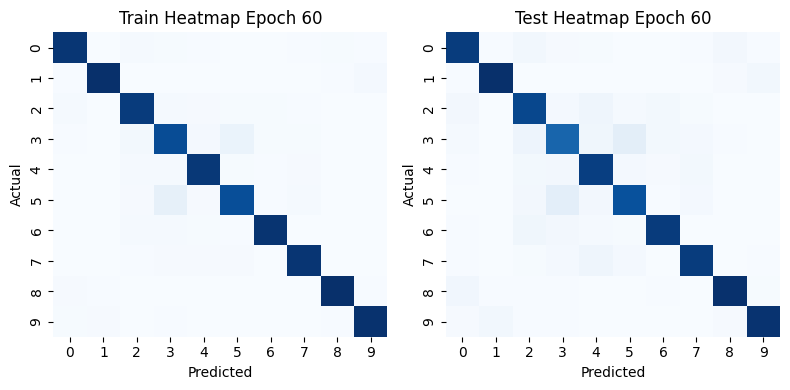

<Figure size 1200x600 with 0 Axes>

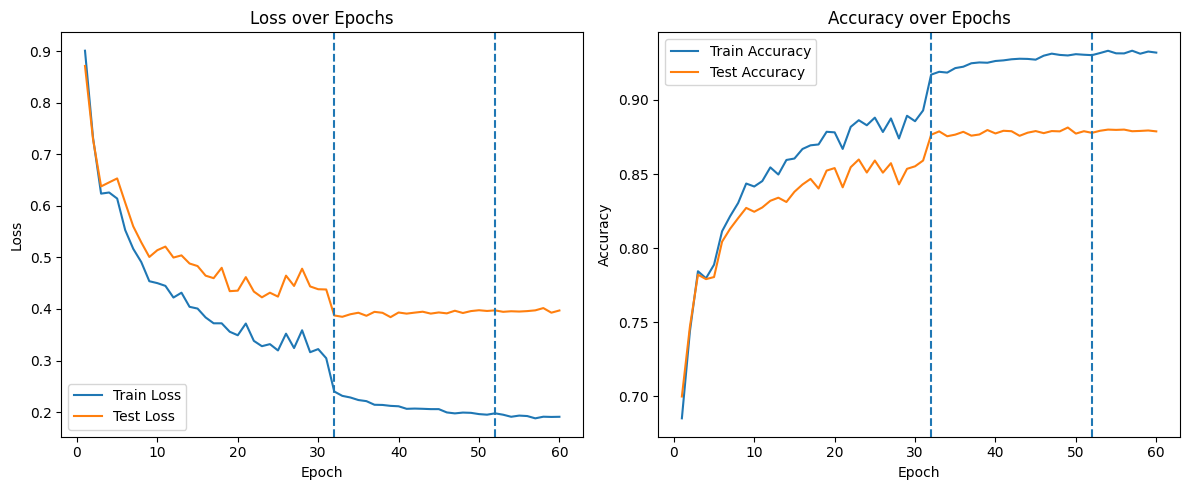

In [8]:
trainf32(model37_1,"model_weights/model37_1.pt",criterion,train_dataset,val_dataset, batch_size=64)